# Sites generalization results analysis

### This file handles the results of the sites generalization results done in `run_experiments.ipynb` (site-specific and leave one site out), and generates the table seen in the paper


In [15]:
from dotenv import load_dotenv
from pathlib import Path
import sys
import os

# Walk up until we find the project root (folder with the .env)
current_path = Path().resolve()
for parent in [current_path] + list(current_path.parents):
    if (parent / ".env").exists():
        load_dotenv(parent / ".env")
        project_root = os.getenv("PROJECT_ROOT")
        print(project_root)
        sys.path.append(project_root)     
        break


%load_ext autoreload
%autoreload 2

/Users/emmanuelfernandez/Documents/beluga-call-pipeline
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:

import os
import json
import pandas as pd

In [17]:
results_dir = "../new_results/sites_generalization_include_sample_last"
runs = [d for d in os.listdir(results_dir) if os.path.isdir(os.path.join(results_dir, d))]
leave_one_out_runs = [run for run in runs if "out" in run]


In [18]:

sites = ["BSM", "CAC", "KAM", "RDL"]

results = {}
for run in runs:
    results_path = os.path.join(results_dir, run, "training_details.json")
    if os.path.exists(results_path):
        with open(results_path, 'r') as f:
            res = json.load(f)
            results[run] = {
                "main": res["testing_metrics"],
            }
            if "other_tests" in res:
                for test_name, test_metrics in res["other_tests"].items():
                    results[run][test_name] = test_metrics


In [19]:
runs

['leave_RDL_out_include_400',
 'leave_KAM_out_include_300',
 'leave_BSM_out_include_400',
 'leave_CAC_out_include_500',
 'leave_CAC_out_include_100',
 'leave_CAC_out_include_0_qat',
 'leave_KAM_out_include_400',
 'leave_BSM_out_include_300',
 'leave_RDL_out_include_300',
 'leave_BSM_out_include_0',
 'leave_CAC_out_include_200',
 'leave_BSM_out_include_200',
 'leave_KAM_out_include_500',
 'leave_BSM_out_include_400_qat',
 'leave_RDL_out_include_0_qat',
 'leave_KAM_out_include_500_qat',
 'leave_CAC_out_include_200_qat',
 'leave_RDL_out_include_500_qat',
 'leave_RDL_out_include_200',
 'leave_KAM_out_include_100',
 'leave_BSM_out_include_0_qat',
 'leave_BSM_out_include_200_qat',
 'leave_CAC_out_include_400_qat',
 'leave_RDL_out_include_100_qat',
 'leave_KAM_out_include_300_qat',
 'leave_KAM_out_include_100_qat',
 'leave_RDL_out_include_300_qat',
 'leave_CAC_out_include_300',
 'leave_KAM_out_include_0_qat',
 'leave_CAC_out_include_0',
 'leave_RDL_out_include_400_qat',
 'leave_CAC_out_includ

In [20]:
results

{'leave_RDL_out_include_400': {'main': {'time_elapsed': 1.5424416065216064,
   'loss': 36.54069412698348,
   'accuracy': {'Labels_Average': 0.9466666579246521,
    'ECHO': 0.9288889169692993,
    'HFPC': 0.9622222185134888,
    'BBPC': 0.9399999976158142,
    'Whistle': 0.9555555582046509},
   'f1': {'Labels_Average': 0.8747222423553467,
    'ECHO': 0.8399999737739563,
    'HFPC': 0.884353756904602,
    'BBPC': 0.8491619825363159,
    'Whistle': 0.9253731369972229},
   'precision': {'Labels_Average': 0.8757787942886353,
    'ECHO': 0.8571428656578064,
    'HFPC': 0.8666666746139526,
    'BBPC': 0.8539325594902039,
    'Whistle': 0.9253731369972229},
   'recall': {'Labels_Average': 0.8740311861038208,
    'ECHO': 0.8235294222831726,
    'HFPC': 0.9027777910232544,
    'BBPC': 0.8444444537162781,
    'Whistle': 0.9253731369972229},
   'AUC': {'Labels_Average': 0.9748184084892273,
    'ECHO': 0.9626577496528625,
    'HFPC': 0.9907407164573669,
    'BBPC': 0.9640123844146729,
    'Whistle'

Values of 'f1.Labels_Average' when 0 samples are present:
  Site: BSM  f1.Labels_Average: 0.7447624206542969
  Site: CAC  f1.Labels_Average: 0.754833996295929
  Site: KAM  f1.Labels_Average: 0.7523752450942993
  Site: RDL  f1.Labels_Average: 0.8512029647827148


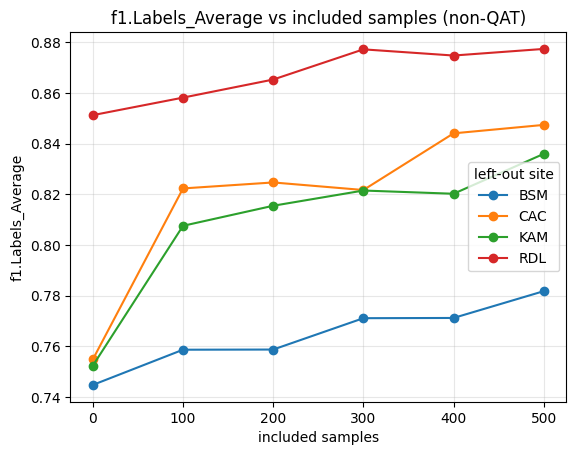

In [29]:
import re
from typing import Dict, Any, Optional, Tuple, Iterable

import pandas as pd
import matplotlib.pyplot as plt


_KEY_RE = re.compile(r"^leave_(?P<site>[A-Za-z0-9]+)_out_include_(?P<samples>\d+)(?P<qat>_qat)?$")


def results_to_df(
    results: Dict[str, Dict[str, Any]],
    *,
    test_set: str = "main",
    drop_qat: bool = True,
    keep_sites: Optional[Iterable[str]] = None,
) -> pd.DataFrame:
    """
    Parse results dict keys like:
        leave_BSM_out_include_0
        leave_BSM_out_include_100_qat

    test_set: "main", "Boat_1.0", or "Boat_0.0"
    """
    rows = []
    keep_sites = set(keep_sites) if keep_sites is not None else None

    for k, v in results.items():
        m = _KEY_RE.match(k)
        if not m:
            continue

        site = m.group("site")
        samples = int(m.group("samples"))
        is_qat = m.group("qat") is not None

        if drop_qat and is_qat:
            continue
        if keep_sites is not None and site not in keep_sites:
            continue

        metrics = v.get(test_set, None)
        if metrics is None:
            continue

        row = {
            "run_key": k,
            "site": site,
            "samples": samples,
            "is_qat": is_qat,
            "time_elapsed": metrics.get("time_elapsed", None),
            "loss": metrics.get("loss", None),
        }

        for metric_name in ("accuracy", "f1", "precision", "recall"):
            metric_dict = metrics.get(metric_name, None)
            if isinstance(metric_dict, dict):
                for cls_name, val in metric_dict.items():
                    row[f"{metric_name}.{cls_name}"] = val

        rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df = df.sort_values(["site", "samples"]).reset_index(drop=True)
    return df


def plot_metric_vs_samples(
    results: Dict[str, Dict[str, Any]],
    *,
    metric: str,
    cls: str = "Labels_Average",
    test_set: str = "main",
    drop_qat: bool = True,
    site: Optional[str] = None,
    keep_sites: Optional[Iterable[str]] = None,
    title: Optional[str] = None,
    ax: Optional[plt.Axes] = None,
) -> Tuple[pd.DataFrame, plt.Axes]:
    """
    Plots samples vs metric for leave-site-out runs.
    test_set: "main", "Boat_1.0", or "Boat_0.0"
    """
    df = results_to_df(results, test_set=test_set, drop_qat=drop_qat, keep_sites=keep_sites)

    if df.empty:
        raise ValueError("No rows parsed from results. Check key format / drop_qat / test_set setting.")

    if metric == "loss":
        y_col = "loss"
    else:
        y_col = f"{metric}.{cls}"
        if y_col not in df.columns:
            available = sorted([c for c in df.columns if c.startswith(metric + ".")])
            raise KeyError(
                f"Column '{y_col}' not found. Available for metric='{metric}': {available}"
            )

    if ax is None:
        _, ax = plt.subplots()

    if site is not None:
        d = df[df["site"] == site].sort_values("samples")
        if d.empty:
            raise ValueError(f"No rows for site='{site}'. Sites present: {sorted(df['site'].unique())}")
        ax.plot(d["samples"], d[y_col], marker="o", label=site)
    else:
        for s, d in df.groupby("site", sort=True):
            d = d.sort_values("samples")
            ax.plot(d["samples"], d[y_col], marker="o", label=s)
        ax.legend(title="left-out site", loc="best")

    ax.set_xlabel("included samples")
    ax.set_ylabel(y_col)
    ax.grid(True, alpha=0.3)

    if title is None:
        base = f"{y_col} vs included samples"
        if test_set != "main":
            base += f" ({test_set})"
        if drop_qat:
            base += " (non-QAT)"
        title = base
    ax.set_title(title)

    zero_samples_df = df[df["samples"] == 0]
    if not zero_samples_df.empty:
        print(f"Values of '{y_col}' when 0 samples are present:")
        for site_name, row in zero_samples_df.iterrows():
            print(f"  Site: {row['site']}  {y_col}: {row[y_col]}")
    else:
        print(f"No entries found with 0 samples present for '{y_col}'.")

    return df, ax


# ---- Example usage ----
df, ax = plot_metric_vs_samples(results, metric="f1", cls="Labels_Average", drop_qat=True)
# df, ax = plot_metric_vs_samples(results, metric="f1", cls="ECHO", drop_qat=True)
# df, ax = plot_metric_vs_samples(results, metric="f1", cls="HFPC", drop_qat=True)
# df, ax = plot_metric_vs_samples(results, metric="f1", cls="BBPC", drop_qat=True)
# df, ax = plot_metric_vs_samples(results, metric="f1", cls="Whistle", drop_qat=True)
plt.show()

In [7]:
import pandas as pd

# Build a summary table for leave-one-out results
rows = []
for run in results:
    for site in sites:
        print(f"Processing run: {run}, site: {site}")
        print(results[run].keys())
        if "metrics_dict" not in results[run]:
            print(f"Warning: 'metrics_dict' not found for run {run}. Skipping.")
            continue
        metrics_dict = results[run]["metrics_dict"]["other_tests"]
        

        row = {
            "run": run,
            "site": site,
            "F1 Score Macro": f"{metrics_dict[site]['f1']['Labels_Average']["mean"]:.3f}",
            "ECHO F1": f"{metrics_dict[site]['f1']['ECHO']["mean"]:.3f}",
            "BBPC F1": f"{metrics_dict[site]['f1']['BBPC']["mean"]:.3f}",
            "HFPC F1": f"{metrics_dict[site]['f1']['HFPC']["mean"]:.3f}",
            "Whistle F1": f"{metrics_dict[site]['f1']['Whistle']["mean"]:.3f}",

            "Precision Macro": f"{metrics_dict[site]['precision']['Labels_Average']["mean"]:.3f}",
            "ECHO Precision": f"{metrics_dict[site]['precision']['ECHO']["mean"]:.3f}", 
            "BBPC Precision": f"{metrics_dict[site]['precision']['BBPC']["mean"]:.3f}",
            "HFPC Precision": f"{metrics_dict[site]['precision']['HFPC']["mean"]:.3f}",
            "Whistle Precision": f"{metrics_dict[site]['precision']['Whistle']["mean"]:.3f}",

            "Recall Macro": f"{metrics_dict[site]['recall']['Labels_Average']["mean"]:.3f}",
            "ECHO Recall": f"{metrics_dict[site]['recall']['ECHO']["mean"]:.3f}",
            "BBPC Recall": f"{metrics_dict[site]['recall']['BBPC']["mean"]:.3f}", 
            "HFPC Recall": f"{metrics_dict[site]['recall']['HFPC']["mean"]:.3f}",
            "Whistle Recall": f"{metrics_dict[site]['recall']['Whistle']["mean"]:.3f}",
        }

        rows.append(row)

        # if run.endswith("_qat"):
        if "_qat" in run:
            test_key = site +"_quantized"
            
            quantized_row = {
                "run": run + "_8bit",
                "site": site,
                "F1 Score Macro": f"{metrics_dict[test_key]['f1']['Labels_Average']["mean"]:.3f}",
                "ECHO F1": f"{metrics_dict[test_key]['f1']['ECHO']["mean"]:.3f}",
                "BBPC F1": f"{metrics_dict[test_key]['f1']['BBPC']["mean"]:.3f}",
                "HFPC F1": f"{metrics_dict[test_key]['f1']['HFPC']["mean"]:.3f}",
                "Whistle F1": f"{metrics_dict[test_key]['f1']['Whistle']["mean"]:.3f}",

                "Precision Macro": f"{metrics_dict[test_key]['precision']['Labels_Average']["mean"]:.3f}",
                "ECHO Precision": f"{metrics_dict[test_key]['precision']['ECHO']["mean"]:.3f}", 
                "BBPC Precision": f"{metrics_dict[test_key]['precision']['BBPC']["mean"]:.3f}",
                "HFPC Precision": f"{metrics_dict[test_key]['precision']['HFPC']["mean"]:.3f}",
                "Whistle Precision": f"{metrics_dict[test_key]['precision']['Whistle']["mean"]:.3f}",

                "Recall Macro": f"{metrics_dict[test_key]['recall']['Labels_Average']["mean"]:.3f}",
                "ECHO Recall": f"{metrics_dict[test_key]['recall']['ECHO']["mean"]:.3f}",
                "BBPC Recall": f"{metrics_dict[test_key]['recall']['BBPC']["mean"]:.3f}", 
                "HFPC Recall": f"{metrics_dict[test_key]['recall']['HFPC']["mean"]:.3f}",
                "Whistle Recall": f"{metrics_dict[test_key]['recall']['Whistle']["mean"]:.3f}",
            }

            rows.append(quantized_row)
            



generalization_df = pd.DataFrame(rows)

Processing run: leave_CAC_out, site: CAC
dict_keys(['metrics_dict'])
Processing run: leave_CAC_out, site: KAM
dict_keys(['metrics_dict'])
Processing run: leave_CAC_out, site: RDL
dict_keys(['metrics_dict'])
Processing run: leave_KAM_out, site: CAC
dict_keys(['metrics_dict'])
Processing run: leave_KAM_out, site: KAM
dict_keys(['metrics_dict'])
Processing run: leave_KAM_out, site: RDL
dict_keys(['metrics_dict'])
Processing run: leave_RDL_out, site: CAC
dict_keys(['metrics_dict'])
Processing run: leave_RDL_out, site: KAM
dict_keys(['metrics_dict'])
Processing run: leave_RDL_out, site: RDL
dict_keys(['metrics_dict'])


In [8]:
# Step 1: Create pivot and reset index
table = generalization_df.pivot(index='run', columns='site', values='F1 Score Macro').reset_index()
table_filtered = table[~table["run"].str.contains("include")]
table.head(5)

site,run,CAC,KAM,RDL
0,leave_CAC_out,0.787,0.857,0.883
1,leave_KAM_out,0.860,0.629,0.870
2,leave_RDL_out,0.873,0.848,0.813


In [9]:
import pandas as pd

base_runs = table_filtered['run'].str.replace(r'(_qat_8bit|_qat)$', '', regex=True).unique()
# sites = ['BSM', 'CAC', 'KAM', 'RDL']
sites = [ 'CAC', 'KAM', 'RDL']

def get_val(run_base, site, suffix, table):
    full_run = run_base + suffix
    match = table[table['run'] == full_run]
    if not match.empty:
        val = match[site].values[0]
        try:
            return float(val)
        except (ValueError, TypeError):
            return 0.0
    else:
        return 0.0

def generate_final_table(generalization_df, setting):
    table = generalization_df.pivot(index='run', columns='site', values='F1 Score Macro').reset_index()
    table_filtered = table[~table["run"].str.contains("include")]

    base_runs = table_filtered['run'].str.replace(r'(_qat_8bit|_qat)$', '', regex=True).unique()

    # Step 2: Build summary
    summary_rows = []
    for base in base_runs:
        row = {'run': base}
        fp_gaps = []
        qat_gaps = []

        for site in sites:
            fp_val = get_val(base, site, '', table_filtered)
            qat_val = get_val(base, site, '_qat_8bit', table_filtered)
            if setting == "show_both":   
                row[site] = f"{fp_val:.2f} / {qat_val:.2f}"
            elif setting == "qat_only":
                row[site] = f"{qat_val:.2f}"
            else :
                row[site] = f"{fp_val:.2f}"
            

        # Compute generalization gap
        if base == 'All_sites':
            row['Gen. Gap'] = '–'
        elif 'only' in base:
            site_trained = base.split('_')[0].upper()
            other_sites = [s for s in sites if s != site_trained]
            for test_site in other_sites:
                model_fp = get_val(base, test_site, '', table_filtered)
                best_fp = get_val(f"{test_site}_only", test_site, '', table_filtered)
                fp_gaps.append(best_fp - model_fp)

                model_qat = get_val(base, test_site, '_qat_8bit', table_filtered)
                best_qat = get_val(f"{test_site}_only", test_site, '_qat_8bit', table_filtered)
                qat_gaps.append(best_qat - model_qat)

            avg_fp_gap = round(sum(fp_gaps) / len(fp_gaps), 2)
            avg_qat_gap = round(sum(qat_gaps) / len(qat_gaps), 2)
            row['Gen. Gap'] = f"{avg_fp_gap:.2f} / {avg_qat_gap:.2f}"

            if setting == "show_both":   
                row['Gen. Gap'] = f"{avg_fp_gap:.2f} / {avg_qat_gap:.2f}"
            elif setting == "qat_only":
                row['Gen. Gap'] = f"{avg_qat_gap:.2f}"
            else :
                row['Gen. Gap'] = f"{avg_fp_gap:.2f}"

        elif 'leave' in base:
            site_left_out = base.split('_')[1].upper()
            fp_all = get_val('All_sites', site_left_out, '', table_filtered)
            fp_model = get_val(base, site_left_out, '', table_filtered)
            qat_all = get_val('All_sites', site_left_out, '_qat_8bit', table_filtered)
            qat_model = get_val(base, site_left_out, '_qat_8bit', table_filtered)

            fp_gap = round(fp_all - fp_model, 2)
            qat_gap = round(qat_all - qat_model, 2)
            row['Gen. Gap'] = f"{fp_gap:.2f} / {qat_gap:.2f}"
            if setting == "show_both":   
                row['Gen. Gap'] = f"{fp_gap:.2f} / {qat_gap:.2f}"
            elif setting == "qat_only":
                row['Gen. Gap'] = f"{qat_gap:.2f}"
            else :
                row['Gen. Gap'] = f"{fp_gap:.2f}"

        else:
            row['Gen. Gap'] = '–'

        summary_rows.append(row)

    summary_df = pd.DataFrame(summary_rows)
    return summary_df


In [10]:
generate_final_table(generalization_df, setting="show_both")

,run,CAC,KAM,RDL,Gen. Gap
0,leave_CAC_out,0.79 / 0.00,0.86 / 0.00,0.88 / 0.00,-0.79 / 0.00
1,leave_KAM_out,0.86 / 0.00,0.63 / 0.00,0.87 / 0.00,-0.63 / 0.00
2,leave_RDL_out,0.87 / 0.00,0.85 / 0.00,0.81 / 0.00,-0.81 / 0.00


In [16]:
labels_df = pd.read_csv("../../data/Verified_Dataset/labels/labels_merged.csv")
labels_df.groupby("Boat")["Site"].value_counts()

Boat  Site
0.0   CAC     1896
      KAM     1171
      BSM      943
      RDL      348
1.0   KAM     2234
      CAC     1102
      BSM      992
      RDL       27
Name: count, dtype: int64

In [20]:
labels_df["Call"]

0        0
1        0
2        0
3        0
4        0
        ..
15513    0
15514    0
15515    0
15516    0
15517    0
Name: Call, Length: 15518, dtype: int64

In [21]:
labels_df[labels_df["Call"] != 0]["Site"].value_counts()

Site
KAM    2955
CAC    2157
BSM    1185
RDL     363
Name: count, dtype: int64


### As an internal experiment, we tried the leave-one-site-out experiment but iteratively adding samples from the left out site to see how many samples should be used at new sites to achieve the best performance.

In [23]:

table = generalization_df.pivot(index='run', columns='site', values='F1 Score Macro').reset_index()
table_filtered = table[~table["run"].str.endswith("_qat") & ~table["run"].str.contains("_only")]

table_filtered.head(10)

site,run,BSM,CAC,KAM,RDL
0,All_sites,0.925,0.923,0.921,0.912
2,All_sites_qat_8bit,0.921,0.926,0.918,0.907
15,leave_BSM_out,0.905,0.930,0.927,0.909
17,leave_BSM_out_qat_8bit,0.884,0.920,0.919,0.895
18,leave_BSM_out_qat_include_100,0.897,0.927,0.912,0.904
19,leave_BSM_out_qat_include_100_8bit,0.893,0.924,0.909,0.904
20,leave_BSM_out_qat_include_250,0.915,0.924,0.922,0.905
21,leave_BSM_out_qat_include_250_8bit,0.909,0.924,0.921,0.907
22,leave_BSM_out_qat_include_50,0.904,0.931,0.917,0.904
23,leave_BSM_out_qat_include_500,0.912,0.931,0.926,0.916


In [25]:

# First, let's extract the sample sizes from the run names
def extract_sample_size(run_name):
    if 'include' in run_name:
        return int(run_name.split('include_')[1].split('_')[0])
    return 0

# Create a new dataframe with sample sizes
plot_df = table_filtered.copy()
plot_df['sample_size'] = plot_df['run'].apply(extract_sample_size)

plot_df.head(5)

site,run,BSM,CAC,KAM,RDL,sample_size
0,All_sites,0.925,0.923,0.921,0.912,0
2,All_sites_qat_8bit,0.921,0.926,0.918,0.907,0
15,leave_BSM_out,0.905,0.930,0.927,0.909,0
17,leave_BSM_out_qat_8bit,0.884,0.920,0.919,0.895,0
18,leave_BSM_out_qat_include_100,0.897,0.927,0.912,0.904,100


site
run    All_sites_qat_8bit
BSM                 0.921
CAC                 0.926
KAM                 0.918
RDL                 0.907
Name: 2, dtype: object


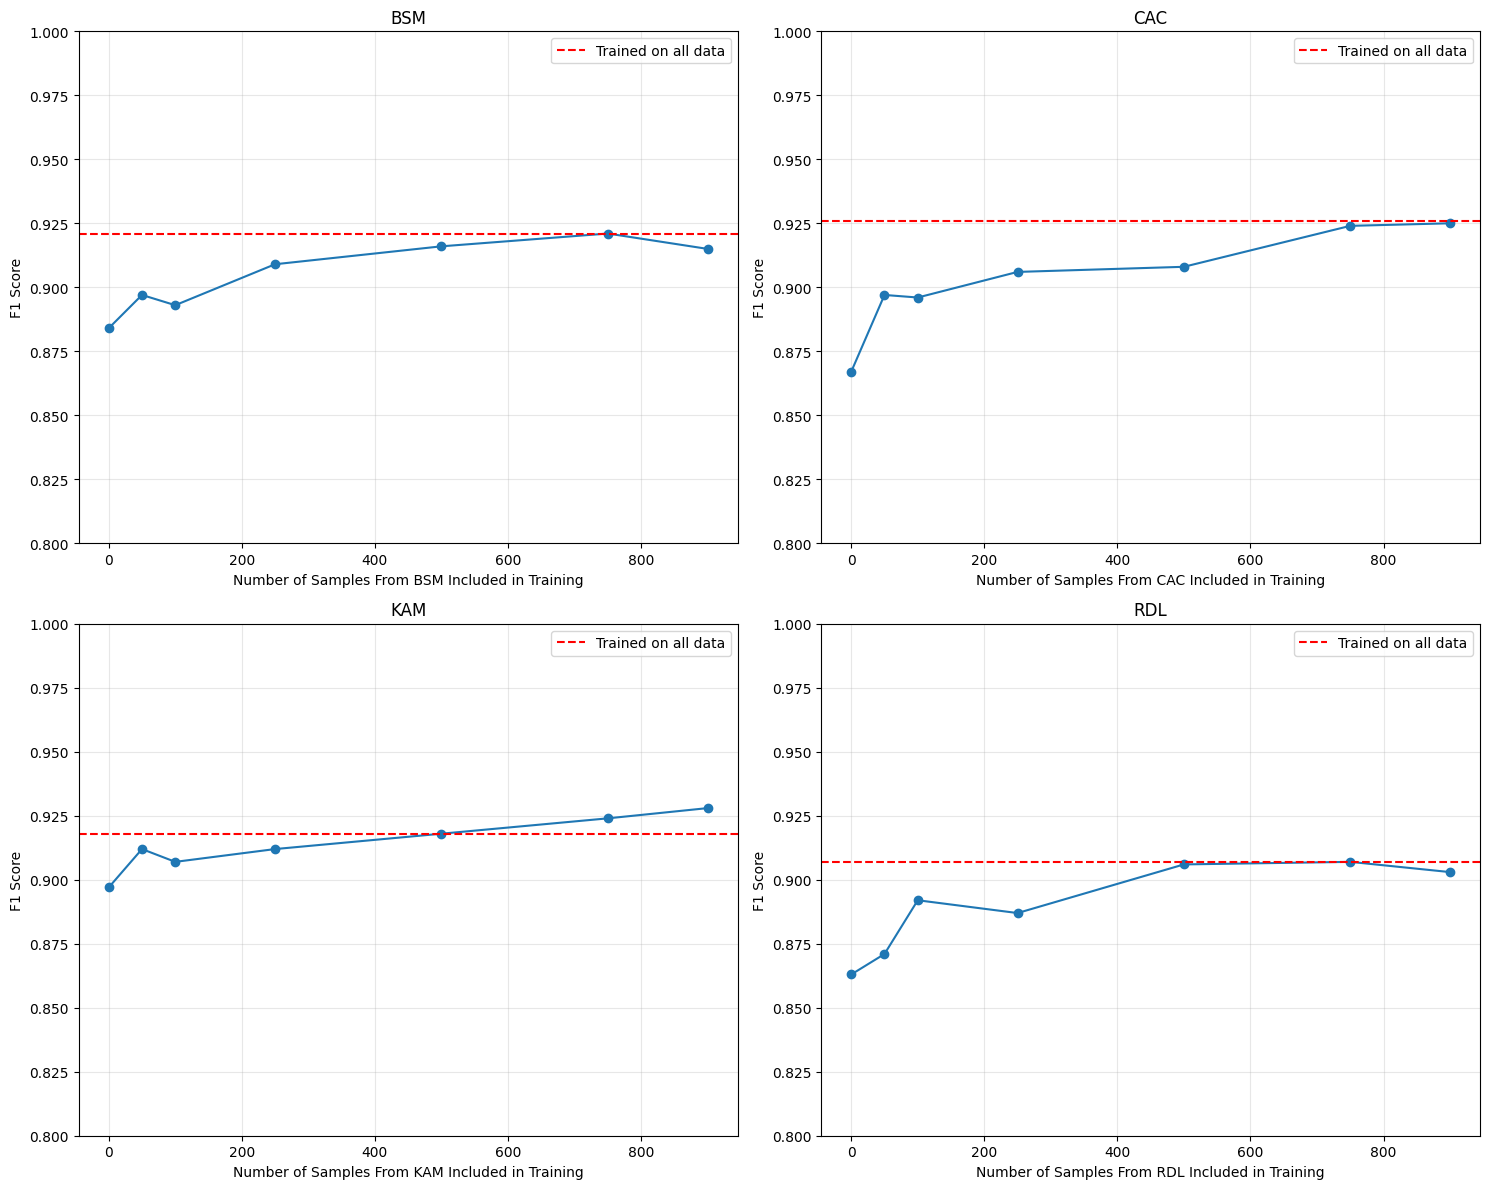

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# Convert all site columns to float
for site in ['BSM', 'CAC', 'KAM', 'RDL']:
    plot_df[site] = plot_df[site].astype(float)

# Get the baseline performance from All_sites
baseline_performance = table_filtered[table_filtered['run'] == 'All_sites_qat_8bit'].iloc[0]

for site in ['BSM', 'CAC', 'KAM', 'RDL']:
    baseline_performance[site] = float(baseline_performance[site])

print(baseline_performance)
# Create a figure with subplots for each site
sites = ['BSM', 'CAC', 'KAM', 'RDL']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, site in enumerate(sites):
    ax = axes[idx]
    
    # Get the baseline for this site
    baseline = baseline_performance[site]
    
    # Filter data for this site's leave-out experiments
    site_data = plot_df[plot_df['run'].str.contains(f'leave_{site}_out') & plot_df['run'].str.contains('8bit')]
    
    site_data = site_data.sort_values('sample_size')

    # Plot the performance line
    ax.plot(site_data['sample_size'], site_data[site], 'o-')
    
    # Add horizontal line for baseline
    ax.axhline(y=baseline, color='r', linestyle='--', label='Trained on all data')
    
    # Customize the plot
    # ax.set_title(f'Leave {site} Out Performance')
    ax.set_title(f'{site}')
    ax.set_xlabel(f'Number of Samples From {site} Included in Training')
    ax.set_ylabel('F1 Score')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Set y-axis limits to be consistent
    ax.set_ylim(0.8, 1.0)

plt.tight_layout()
plt.show()